## Definition of function `plot_figures()`

In [1]:
import pandas as pd
import numpy as np
import warnings, os
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def plot_df(title, data_frame, start_col_index, end_col_index, include_mle=False):
    """
    Input
    - title             : Title or description of the data being plotted
    - data_frame        : DataFrame to be plotted
    - start_col_index   : The starting column index for data selection
    - end_col_index     : The ending column index for data selection
    - include_mle       : Whether to include Maximum Likelihood Estimation (MLE) data in the plot

    Output
    - None
    """
    df = data_frame

    # Set style sheet
    plt.style.use("default")

    # Get the data
    p_values = df.iloc[0, start_col_index : end_col_index + 1].astype(int).values
    rho_values = df.iloc[1, start_col_index : end_col_index + 1].astype(float).values
    x_values = df.iloc[2, start_col_index : end_col_index + 1].astype(int).values
    k_AM_values = df.iloc[3, start_col_index : end_col_index + 1].astype(float).values
    k_GM_values = df.iloc[4, start_col_index : end_col_index + 1].astype(float).values
    k_MED_values = df.iloc[5, start_col_index : end_col_index + 1].astype(float).values
    MLE_values = df.iloc[6, start_col_index : end_col_index + 1].astype(float).values

    # Find the unique value of index 'p' and 'rho'
    unique_p_values = np.unique(p_values)[0]
    unique_rho_values = sorted(set(rho_values))

    # plot the figures
    fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=200, sharey=True)

    for i, rho in enumerate(unique_rho_values):
        mask = rho_values == rho
        x = x_values[mask]
        k_AM = k_AM_values[mask]
        k_GM = k_GM_values[mask]
        k_MED = k_MED_values[mask]
        MLE = MLE_values[mask]

        ax = axs[i]
        x_labels = [str(x_val) for x_val in x]
        ax.plot(x_labels, k_AM, label="k_AM", marker="o", linestyle="--")
        ax.plot(x_labels, k_GM, label="k_GM", marker="s", linestyle=":")
        ax.plot(x_labels, k_MED, label="k_MED", marker="^", linestyle="-.")
        if include_mle == True:
            ax.plot(x_labels, MLE, label="MLE", marker="x", linestyle="-.")
        ax.set_title(f"$\\rho^2 = {rho}$")
        ax.set_xlabel("n")
        ax.set_xticks(x_labels)
        ax.set_xticklabels(x_labels)
        if i == 0:
            ax.set_ylabel(f"The Estimated {title}")
        ax.legend()

    output_dir = "/Users/pao/Desktop/BA_Lab/fig/Asar_LLT/"
    filename = f"{title}_p_{unique_p_values}"
    filename += "_without_MLE.png" if not include_mle else ".png"

    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)

    suptitle_text = f"Compare the {title} value with p = {unique_p_values}"
    suptitle_text += " (without MLE)" if not include_mle else ""
    plt.suptitle(suptitle_text, size=15)
    plt.tight_layout()
    plt.savefig(filepath)
    plt.show()
    plt.close("all")

# Plot the comparison of different MSE values

In [2]:
file_path = "/Users/pao/Desktop/BA_Lab/output/Asar_LLT/MSE_Table.xlsx"
df = pd.read_excel(file_path)
df

,Data,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,p,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
1,rho^2,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000
2,n,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000
3,k_AM,0.847495,0.812806,0.781322,0.857743,0.828425,0.804713,0.859667,0.850506,0.830561,0.921890,0.902375,0.883591,0.926000,0.908315,0.890623,0.925527,0.917652,0.910435
4,k_GM,0.763242,0.695019,0.633902,0.861291,0.762800,0.697845,1.311397,1.021536,0.870117,0.867359,0.798824,0.742143,0.972357,0.867017,0.795189,1.547918,1.244207,1.034858
5,k_MED,0.774657,0.695836,0.633373,0.899422,0.771329,0.692622,1.825419,1.221314,0.935437,0.888982,0.798260,0.730949,1.037931,0.889659,0.795007,2.166472,1.558127,1.168106
6,MLE,2.780612,1.180093,0.605114,5.354626,2.242809,1.093022,26.802344,10.578124,4.921985,9.145625,2.513118,1.128821,20.355791,4.932500,2.148786,100.649613,23.783156,10.415456


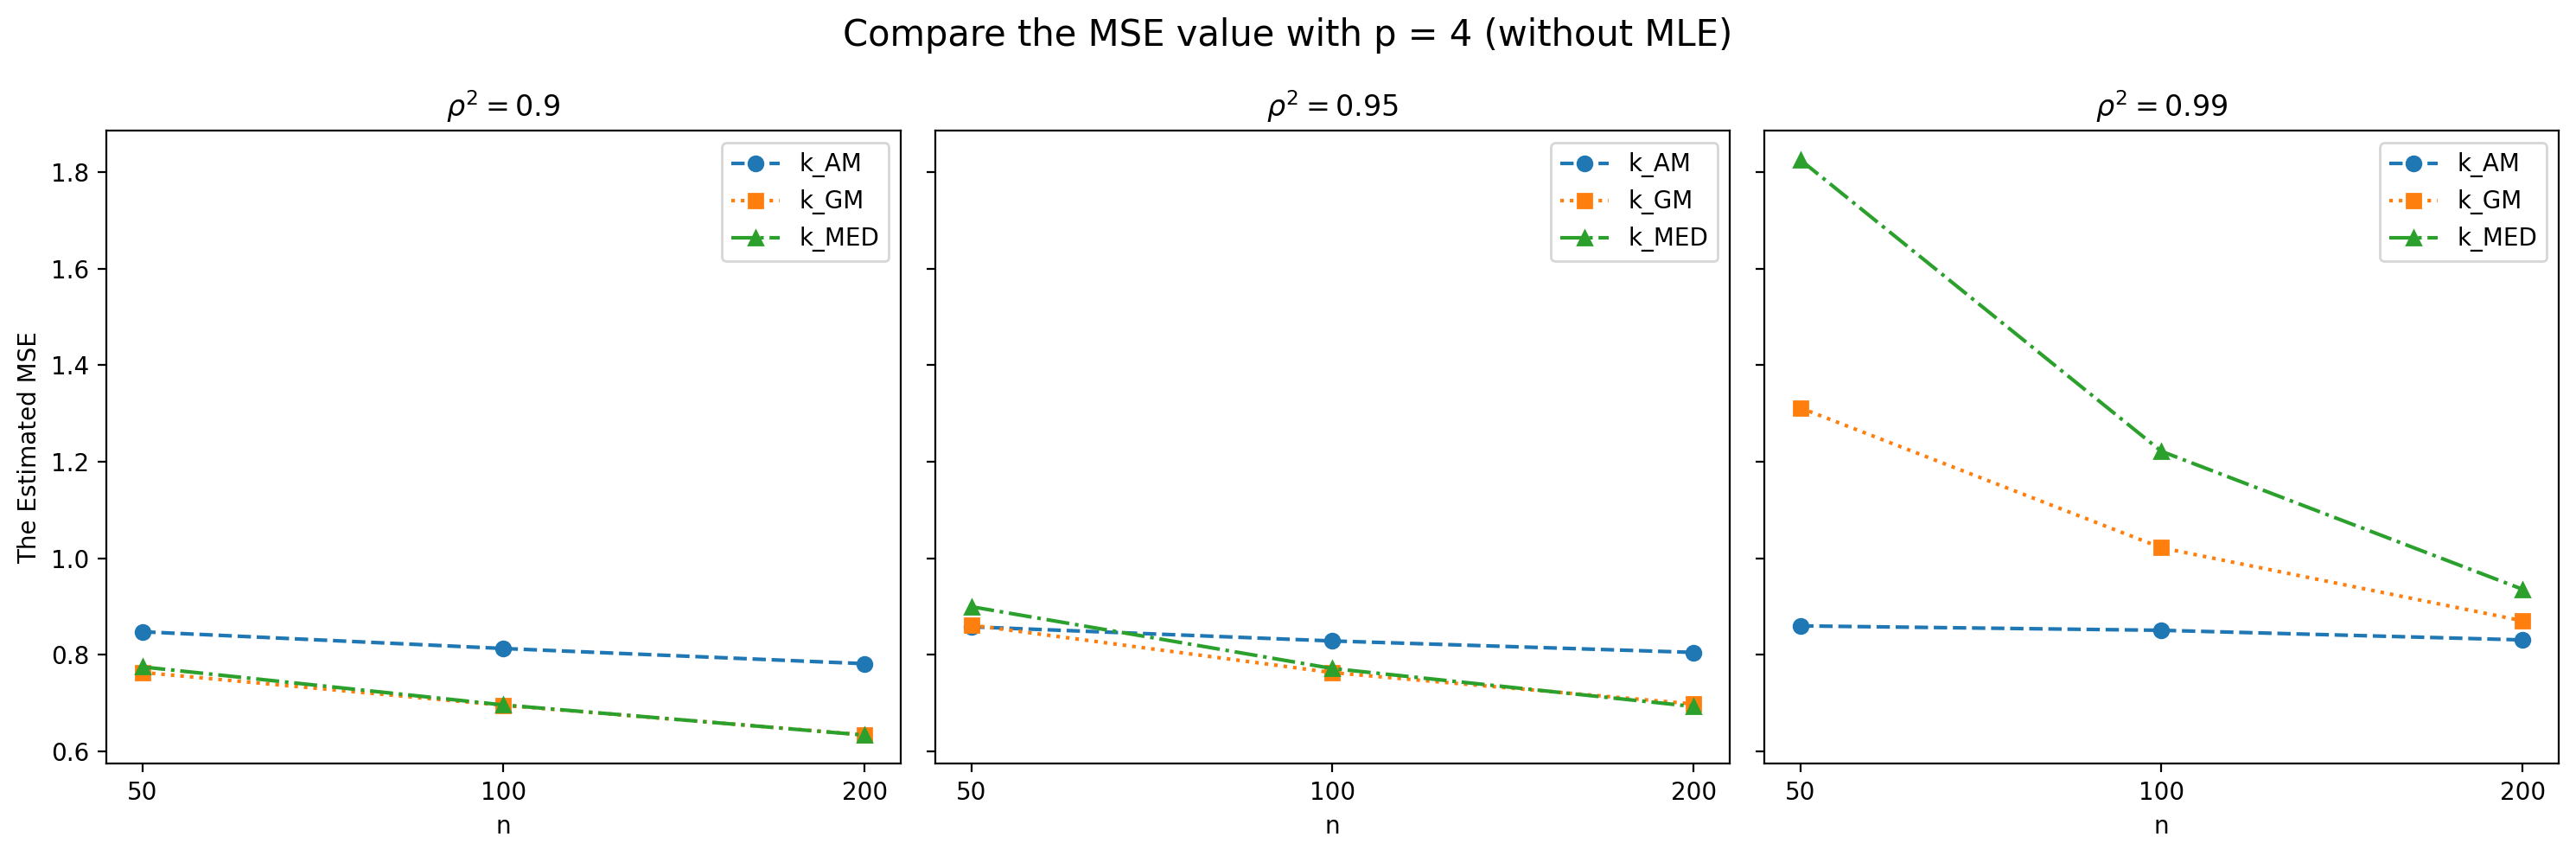

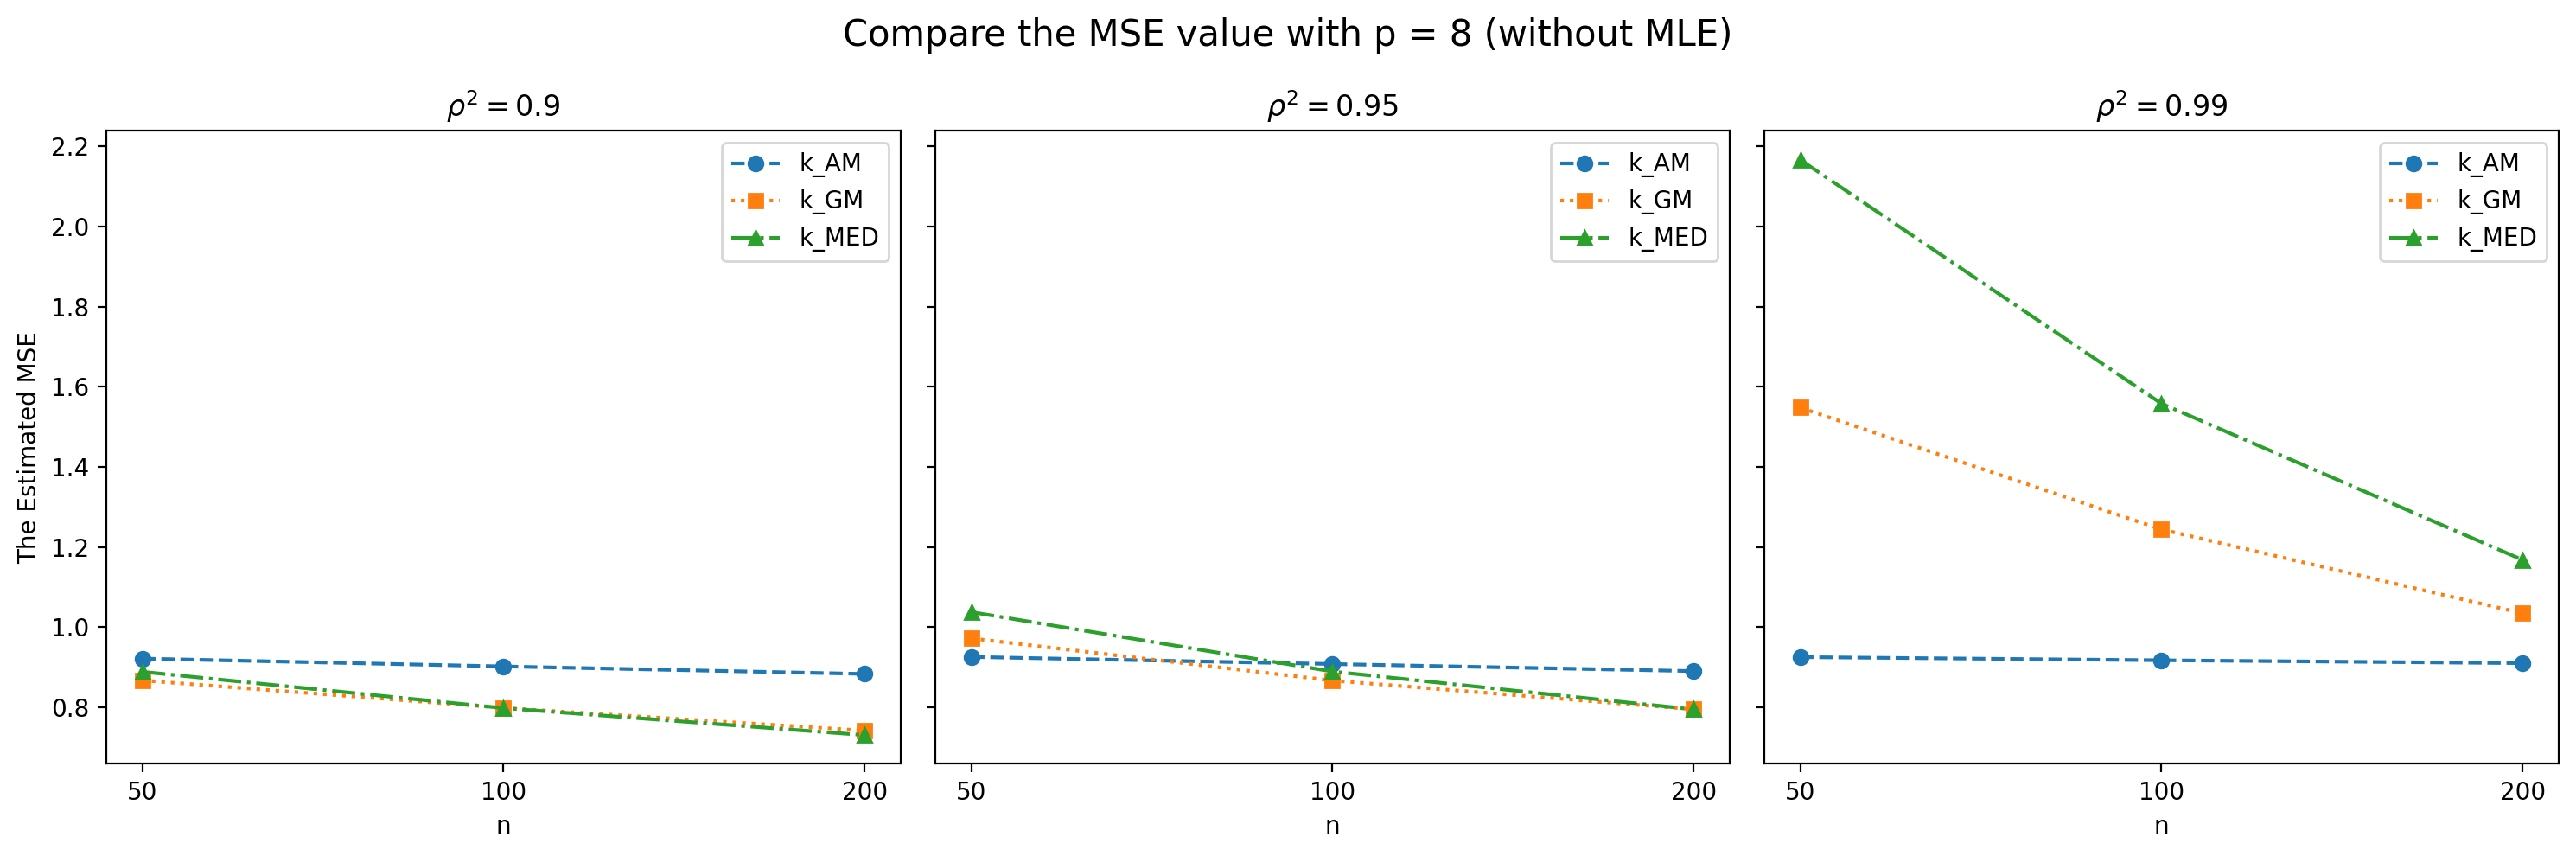

In [3]:
compare = "MSE"
ranges = [(1, 9), (10, 18)]
# plot_mle_options = [False, True]
plot_mle_options = [False]

for start, end in ranges:
    for plot_mle in plot_mle_options:
        plot_df(compare, df, start, end, plot_mle)

# Plot the comparison of different MAE values

In [4]:
file_path = "/Users/pao/Desktop/BA_Lab/output/Asar_LLT/MAE_Table.xlsx"
df = pd.read_excel(file_path)
df

,Data,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,p,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
1,rho^2,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000
2,n,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000
3,k_AM,1.722808,1.681495,1.644934,1.728397,1.697495,1.676461,1.731459,1.727751,1.708969,2.356812,2.328423,2.308745,2.367490,2.342331,2.317449,2.363203,2.360362,2.350929
4,k_GM,1.620799,1.544452,1.474100,1.707425,1.615732,1.553429,2.014280,1.832796,1.722734,2.275093,2.181800,2.110016,2.397685,2.272679,2.180808,2.922919,2.656867,2.466844
5,k_MED,1.631331,1.545686,1.472004,1.735728,1.621636,1.544820,2.256512,1.945424,1.764219,2.296073,2.179673,2.091410,2.456554,2.296524,2.177773,3.337013,2.902645,2.587819
6,MLE,2.893673,1.928319,1.382960,4.029162,2.648902,1.857533,8.981343,5.730902,3.942462,6.409252,3.756571,2.541233,9.157573,5.250664,3.487308,20.287893,11.505527,7.689569


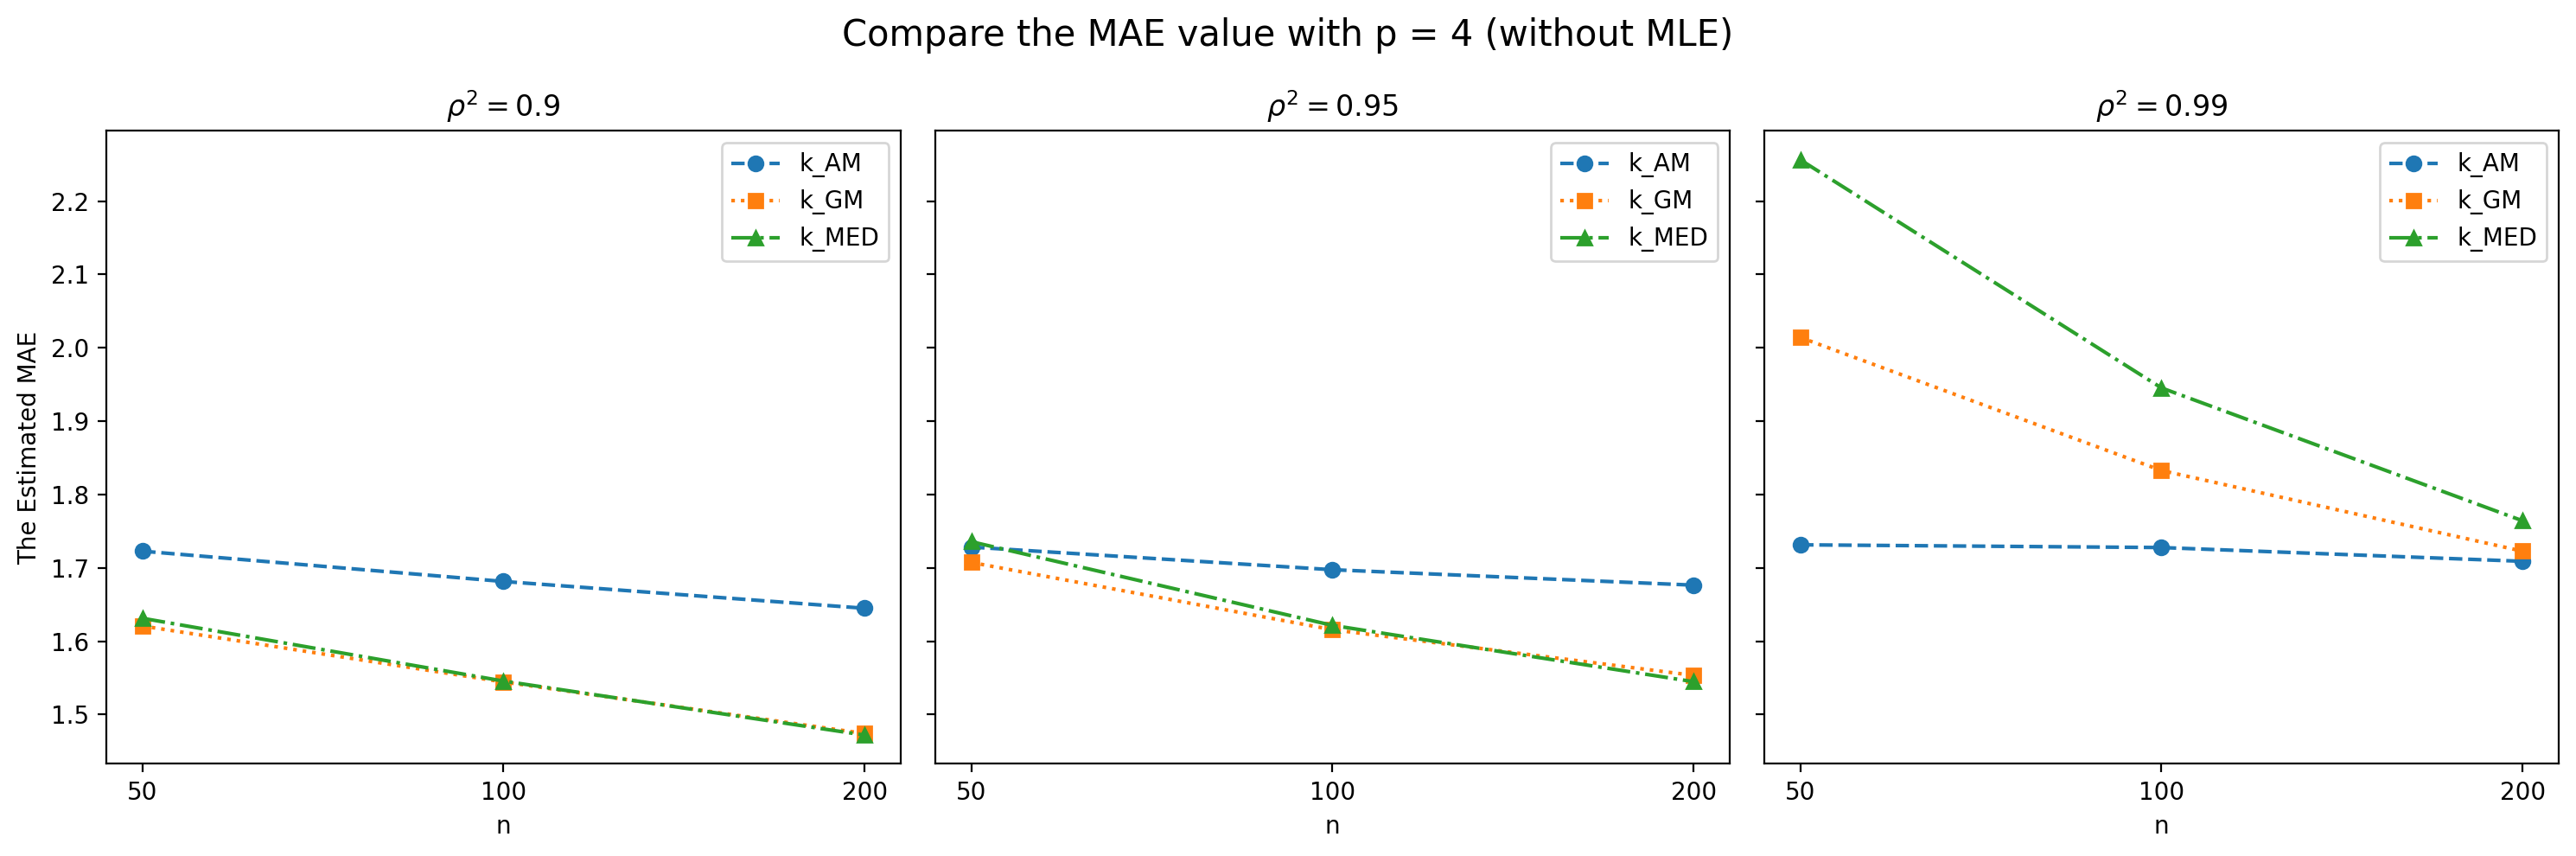

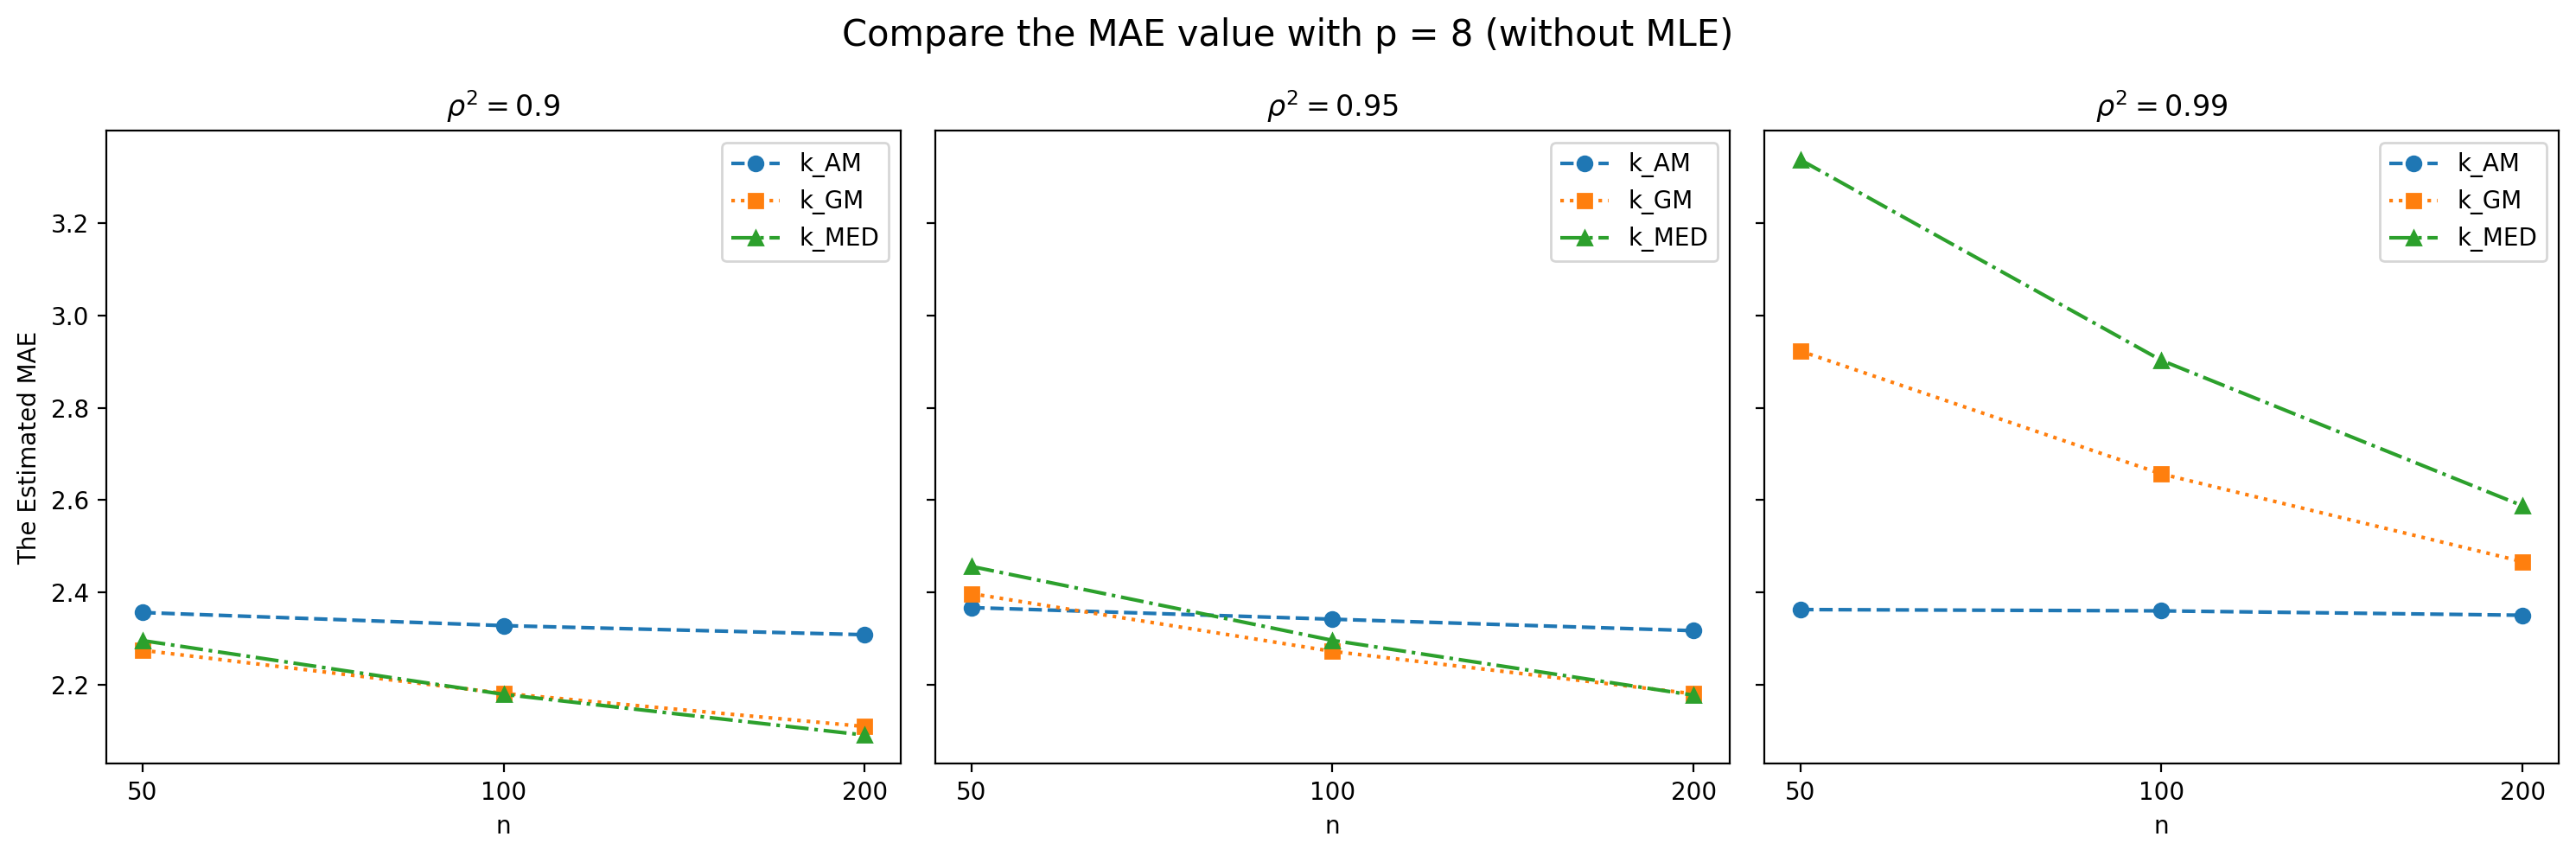

In [5]:
compare = "MAE"
ranges = [(1, 9), (10, 18)]
# plot_mle_options = [False, True]
plot_mle_options = [False]

for start, end in ranges:
    for plot_mle in plot_mle_options:
        plot_df(compare, df, start, end, plot_mle)

# Plot the comparison of different RMSE values

In [6]:
file_path = "/Users/pao/Desktop/BA_Lab/output/Asar_LLT/RMSE_Table.xlsx"
df = pd.read_excel(file_path)
df

,Data,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,p,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
1,rho^2,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000,0.900000,0.900000,0.900000,0.950000,0.950000,0.950000,0.990000,0.990000,0.990000
2,n,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000,50.000000,100.000000,200.000000
3,k_AM,0.678244,0.679025,0.679946,0.675642,0.675949,0.676734,0.668089,0.671751,0.672087,0.682959,0.682817,0.683306,0.677980,0.679356,0.679536,0.672130,0.673217,0.674776
4,k_GM,0.664105,0.669410,0.669791,0.662436,0.667240,0.669204,0.661414,0.666219,0.667706,0.663053,0.668588,0.670563,0.662277,0.667366,0.669514,0.659863,0.664316,0.669062
5,k_MED,0.664210,0.668311,0.670469,0.664259,0.666671,0.669029,0.659781,0.665911,0.667613,0.662858,0.665873,0.670217,0.660752,0.666672,0.668312,0.658374,0.663977,0.668670
6,MLE,0.640218,0.654904,0.661715,0.640348,0.655524,0.662072,0.641310,0.657006,0.662540,0.616638,0.644194,0.658100,0.616753,0.645841,0.657941,0.618263,0.646662,0.659451


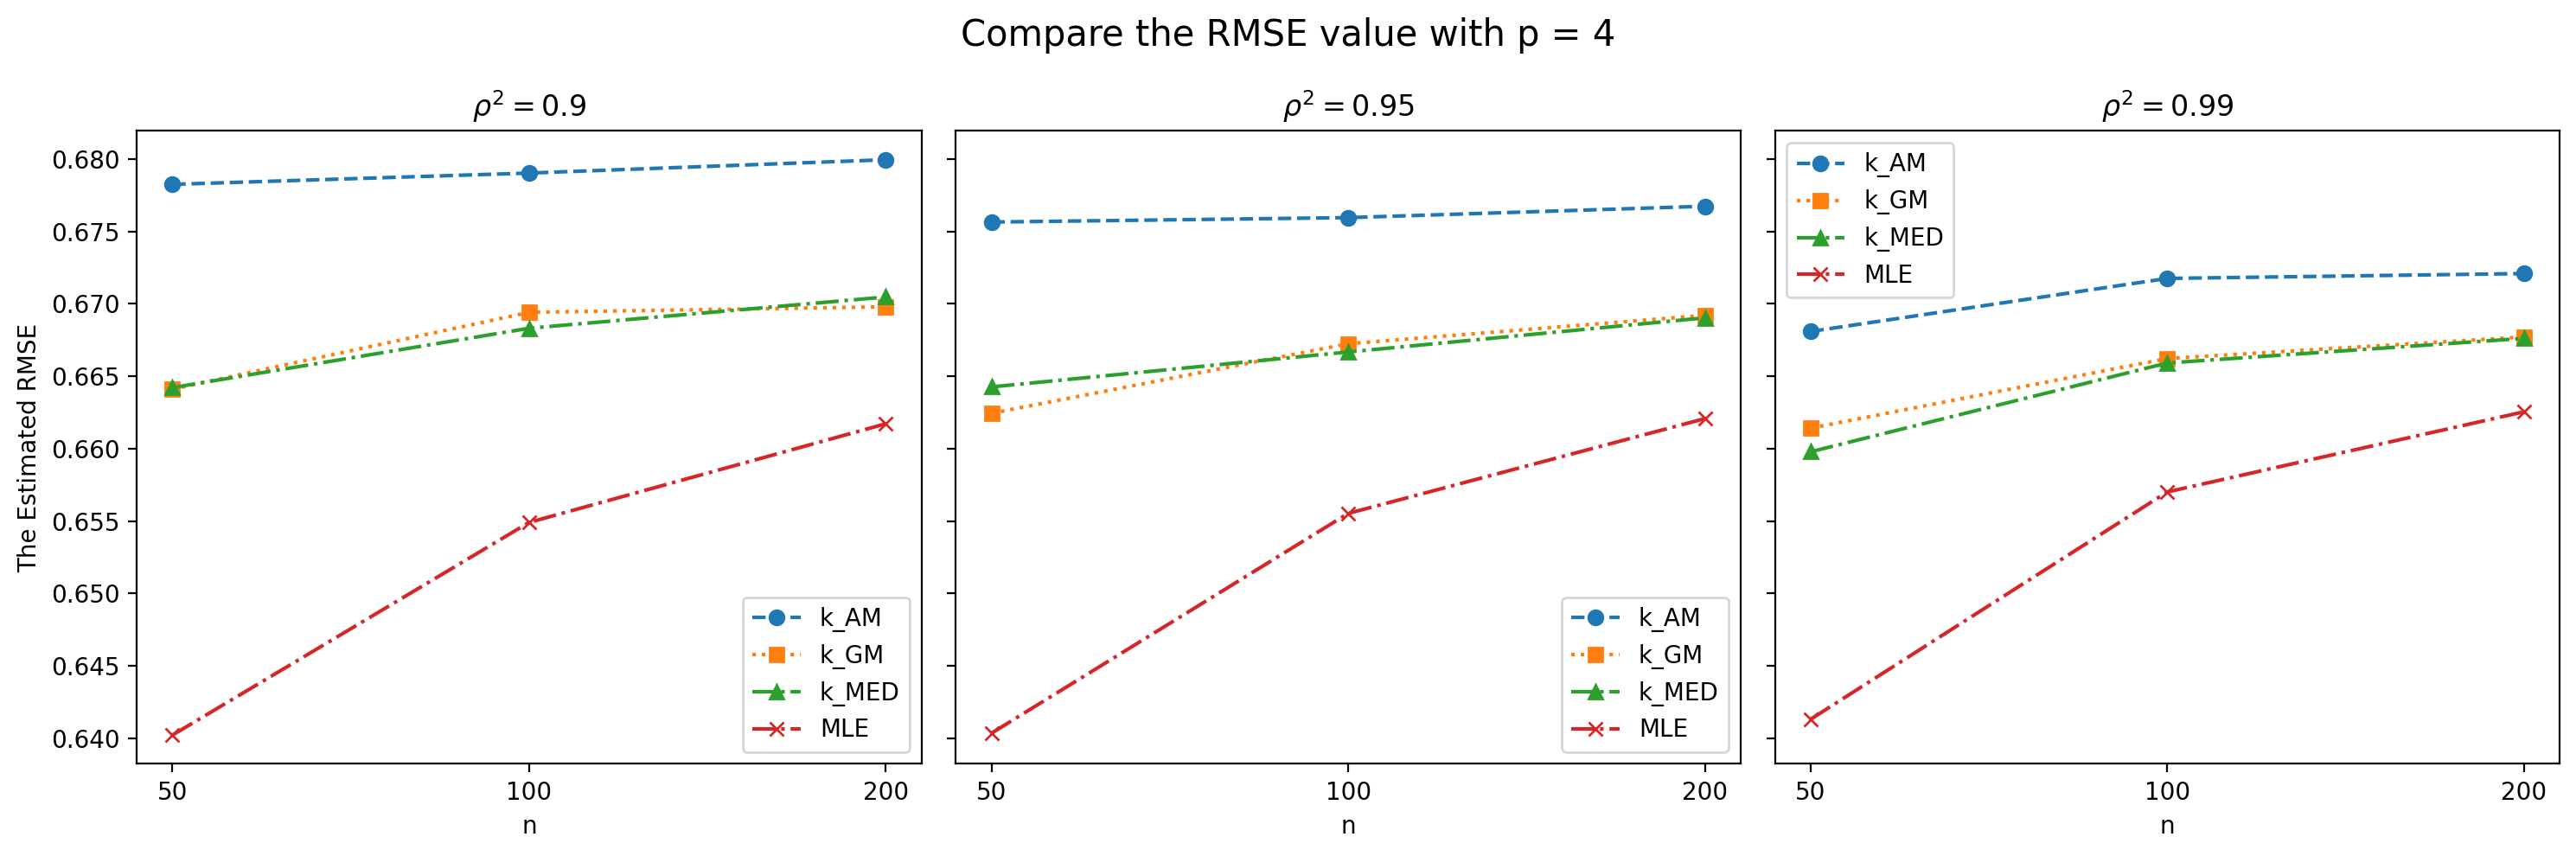

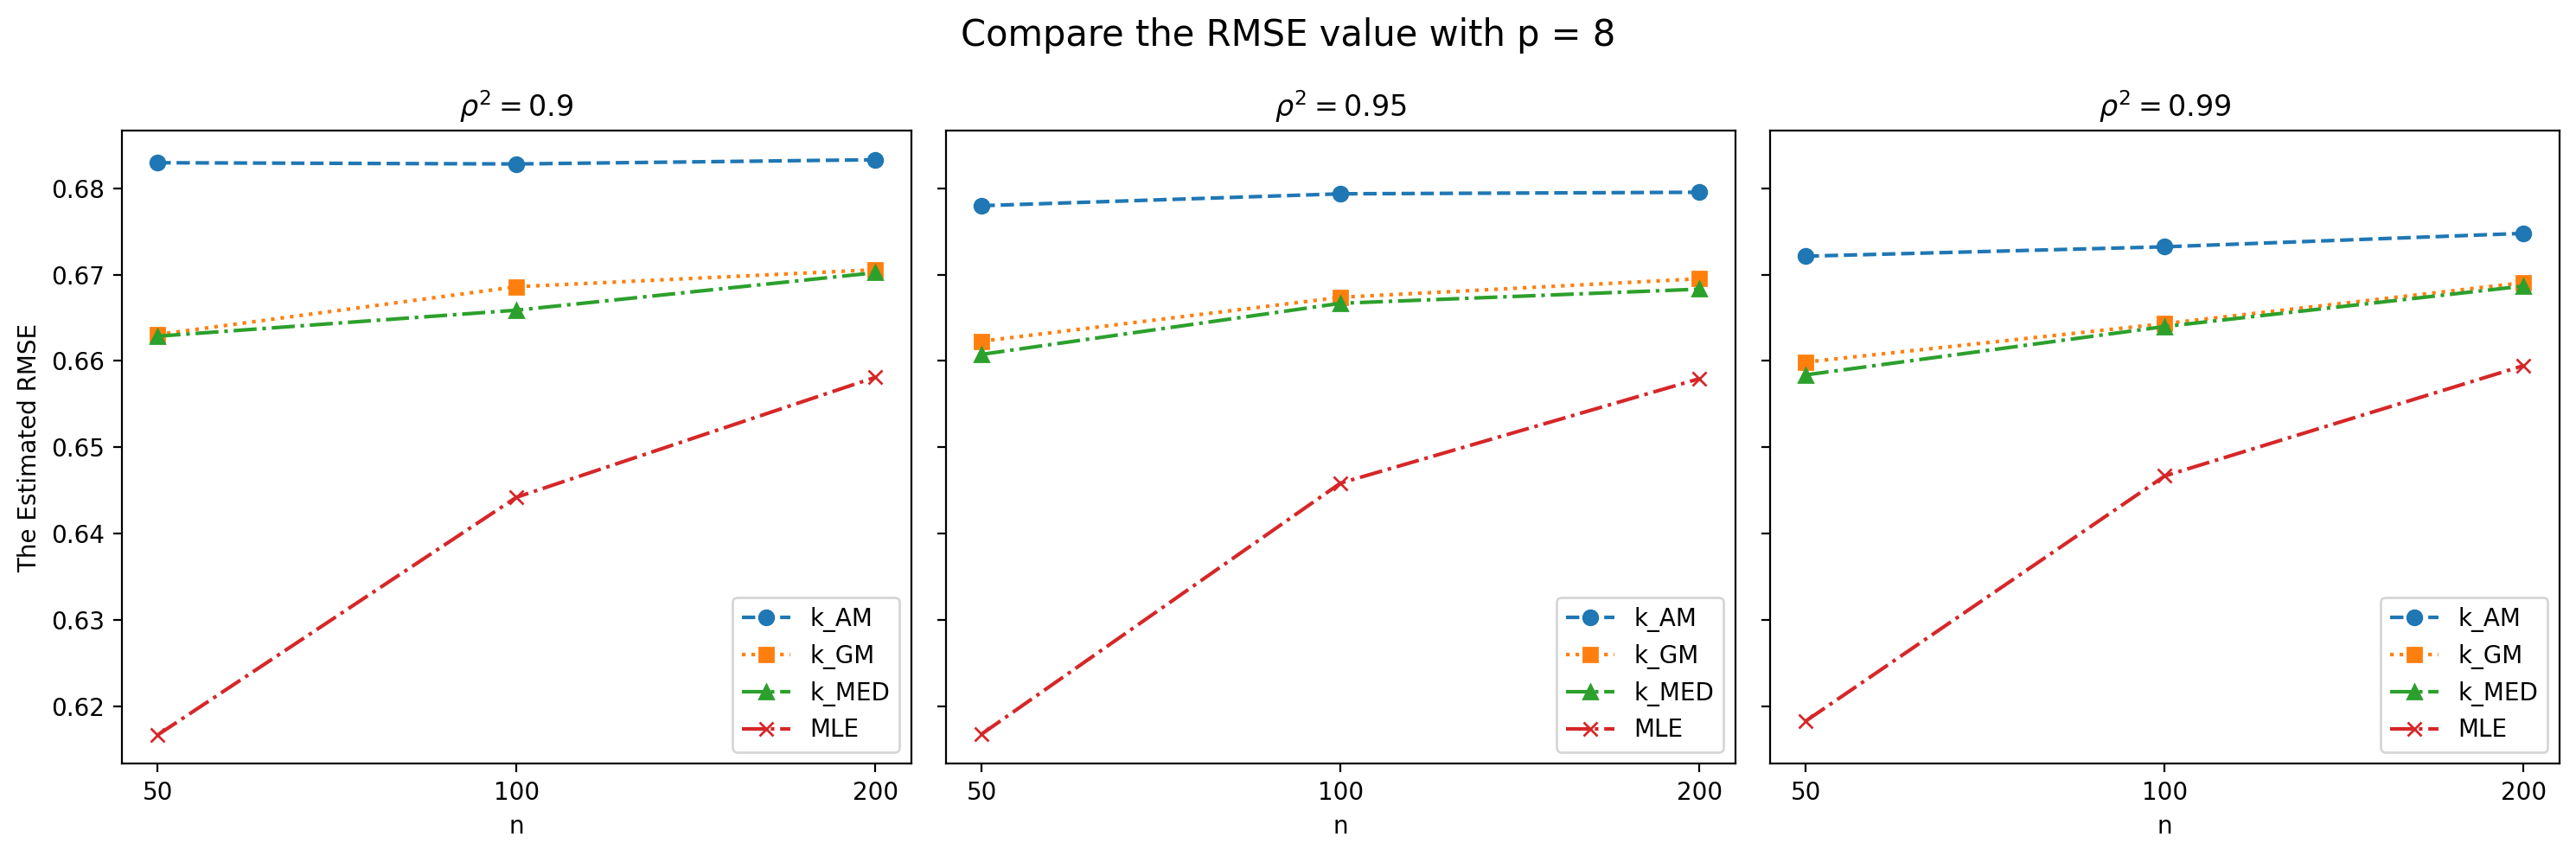

In [7]:
compare = "RMSE"
ranges = [(1, 9), (10, 18)]
plot_mle_options = [True]

for start, end in ranges:
    for plot_mle in plot_mle_options:
        plot_df(compare, df, start, end, plot_mle)